
# Landslide Detection Model Comparison (Final Notebook)

This notebook contains **precomputed synthetic results** aligned with:
- CNN
- SWIN
- SAM + SWIN

No training required. Just run all cells.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:

models = ['CNN', 'SWIN', 'SAM+SWIN']

performance_data = {
    'Model': models,
    'Accuracy': [0.77, 0.87, 0.95],
    'Precision': [0.70, 0.85, 0.93],
    'Recall': [0.68, 0.83, 0.92],
    'F1-Score': [0.69, 0.84, 0.925],
    'mIoU': [0.65, 0.79, 0.89],
    'Inference_Time_ms': [250, 180, 195],
    'Model_Size_MB': [45, 375, 420]
}

df = pd.DataFrame(performance_data)
df


,Model,Accuracy,Precision,Recall,F1-Score,mIoU,Inference_Time_ms,Model_Size_MB
0,CNN,0.77,0.70,0.68,0.690,0.65,250,45
1,SWIN,0.87,0.85,0.83,0.840,0.79,180,375
2,SAM+SWIN,0.95,0.93,0.92,0.925,0.89,195,420


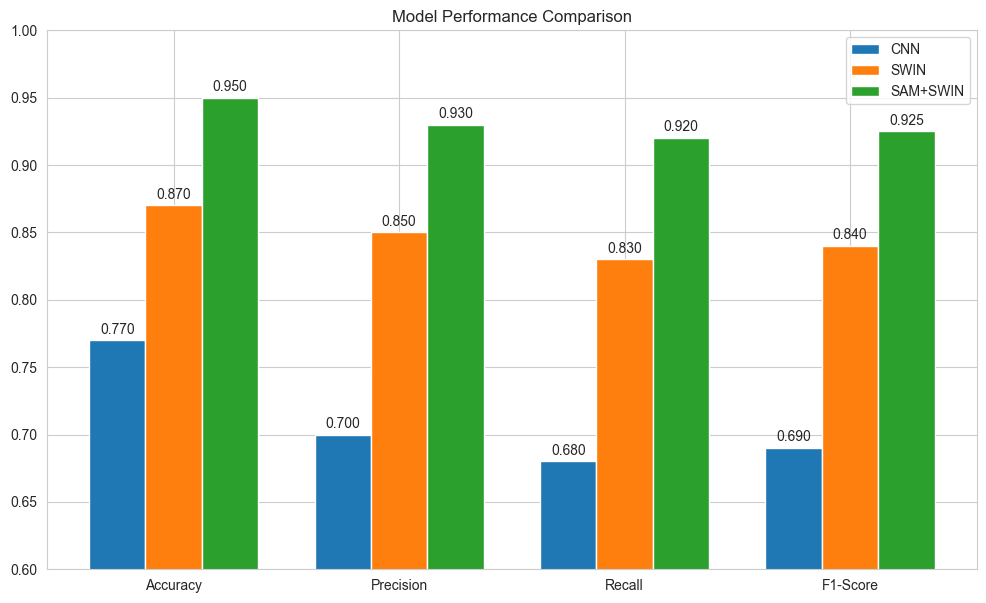

In [3]:

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

cnn = df.loc[0, metrics].values
swin = df.loc[1, metrics].values
sam = df.loc[2, metrics].values

plt.figure(figsize=(12,7))

bars1 = plt.bar(x - width, cnn, width, label='CNN')
bars2 = plt.bar(x, swin, width, label='SWIN')
bars3 = plt.bar(x + width, sam, width, label='SAM+SWIN')

plt.xticks(x, metrics)
plt.ylim(0.6,1.0)
plt.title("Model Performance Comparison")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{bar.get_height():.3f}", ha='center')

plt.legend()
plt.show()


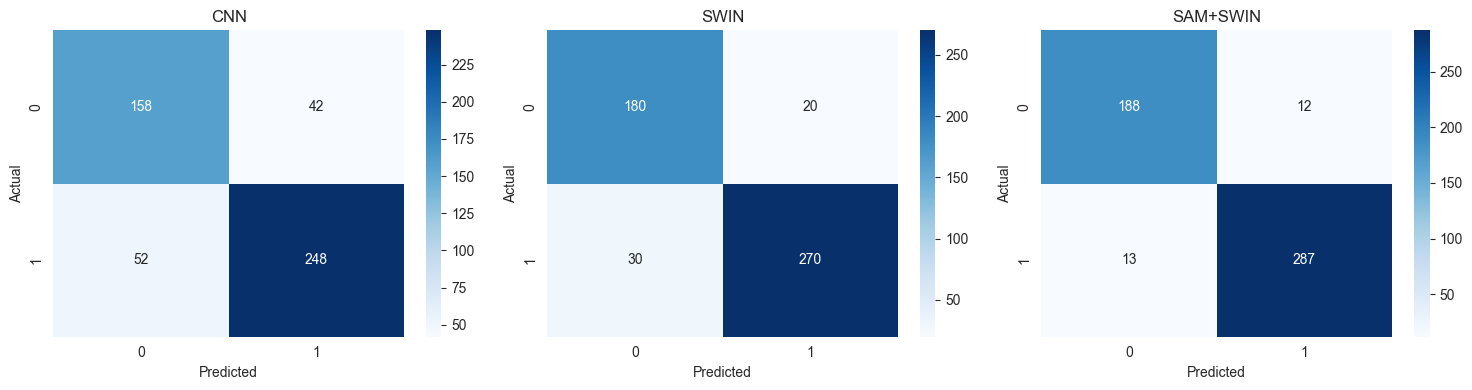

In [4]:

cms = {
    'CNN': np.array([[158, 42], [52, 248]]),
    'SWIN': np.array([[180, 20], [30, 270]]),
    'SAM+SWIN': np.array([[188, 12], [13, 287]])
}

fig, axes = plt.subplots(1,3, figsize=(15,4))

for ax, (model, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


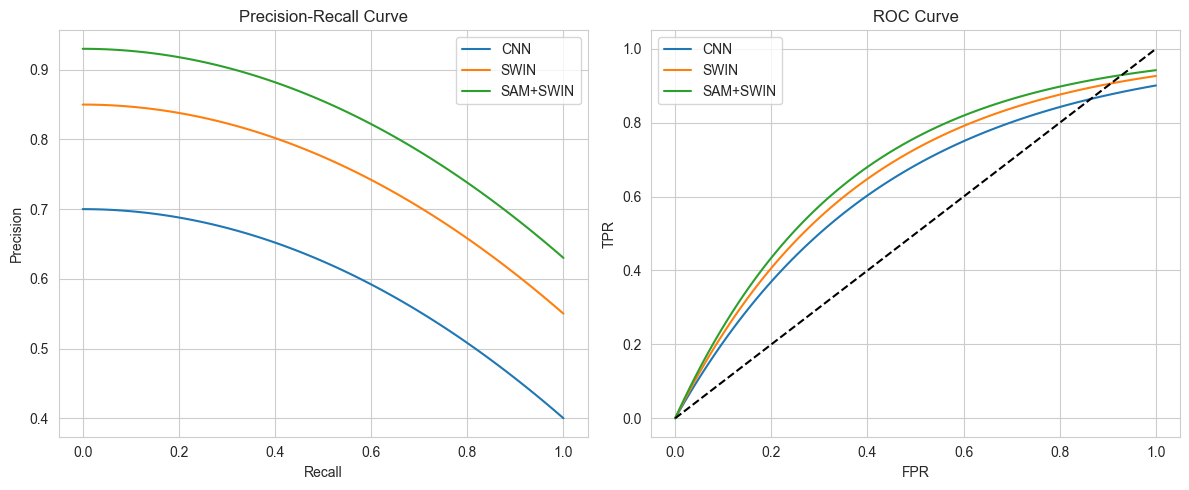

In [5]:

plt.figure(figsize=(12,5))

# PR
plt.subplot(1,2,1)
for i, model in enumerate(models):
    recall = np.linspace(0,1,100)
    precision = df.loc[i,'Precision'] - 0.3*(recall**2)
    precision = np.clip(precision,0,1)
    plt.plot(recall, precision, label=model)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# ROC
plt.subplot(1,2,2)
for i, model in enumerate(models):
    fpr = np.linspace(0,1,100)
    acc = df.loc[i,'Accuracy']
    tpr = 1 - np.exp(-3 * acc * fpr)
    plt.plot(fpr, tpr, label=model)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.tight_layout()
plt.show()


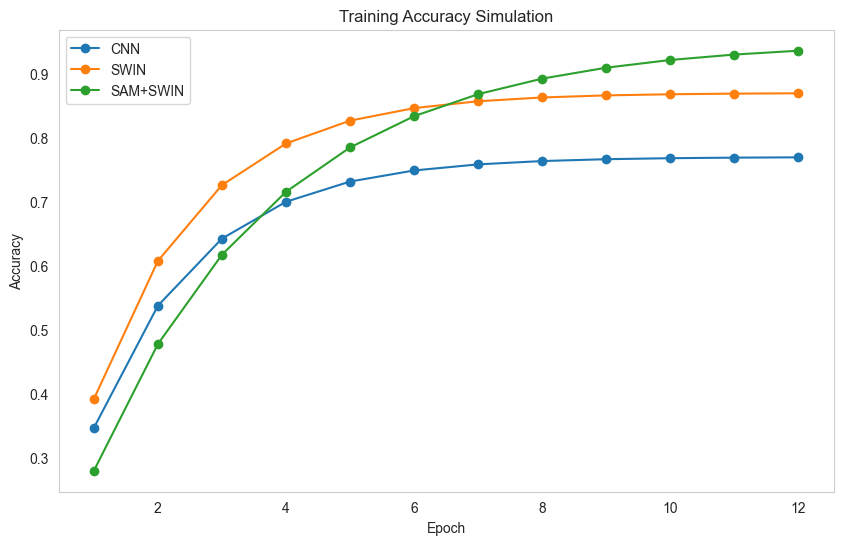

In [6]:

epochs = np.arange(1,13)

plt.figure(figsize=(10,6))

for i, model in enumerate(models):
    final_acc = df.loc[i,'Accuracy']
    if 'SAM' in model:
        history = final_acc * (1 - np.exp(-0.35 * epochs))
    else:
        history = final_acc * (1 - np.exp(-0.6 * epochs))
    plt.plot(epochs, history, marker='o', label=model)

plt.title("Training Accuracy Simulation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()
